# 04 — Anomaly Gate Training — Machine PF30106
### CNN-LSTM Autoencoder trained on healthy data only
> This machine has no breakdown data yet.
> The Anomaly Gate detects States 1, 4, and 5 only.
> Run 00_Data_Preparation_PF30106.ipynb first.

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')

✅ Device: cpu


In [2]:
with open('prepared_data_PF30106.pkl', 'rb') as f: d = pickle.load(f)

X_ae_train = torch.FloatTensor(d['X_ae_train']).to(DEVICE)
X_ae_test  = torch.FloatTensor(d['X_ae_test']).to(DEVICE)
NUM_FEATURES   = d['num_features']
TIME_STEPS     = d['TIME_STEPS']
MACHINE_SERIAL = d['MACHINE_SERIAL']

ae_loader = DataLoader(
    TensorDataset(X_ae_train, X_ae_train),
    batch_size=32, shuffle=True
)

print(f'✅ Data loaded for machine: {MACHINE_SERIAL}')
print(f'   Train shape : {X_ae_train.shape}')
print(f'   Test shape  : {X_ae_test.shape}')
print(f'   NUM_FEATURES: {NUM_FEATURES}')
print(f'   TIME_STEPS  : {TIME_STEPS}')

✅ Data loaded for machine: PF30106
   Train shape : torch.Size([408, 7, 66])
   Test shape  : torch.Size([103, 7, 66])
   NUM_FEATURES: 66
   TIME_STEPS  : 7


## Anomaly Gate — CNN-LSTM Autoencoder
> Trained on healthy data only.
> Learns to reconstruct normal machine behaviour.
> High reconstruction error = anomaly detected.

In [3]:
class AnomalyGate(nn.Module):
    def __init__(self, time_steps, num_features, num_vib=60, num_elec=6):
        super().__init__()
        self.time_steps = time_steps
        self.num_vib    = num_vib
        self.num_elec   = num_elec

        # Encoder
        self.enc_vib_conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2)
        )
        enc_vib_size     = 32 * (num_vib // 2)
        self.enc_lstm    = nn.LSTM(enc_vib_size + num_elec, 32, batch_first=True)
        self.bottleneck  = nn.Linear(32, 16)

        # Decoder
        self.dec_lstm    = nn.LSTM(16, 32, batch_first=True)
        self.dec_out     = nn.Linear(32, num_features)

    def encode(self, x):
        batch   = x.size(0)
        vib_in  = x[:, :, :self.num_vib]
        elec_in = x[:, :, self.num_vib:]
        vib_feats = []
        for t in range(self.time_steps):
            vt = vib_in[:, t, :].unsqueeze(1)
            vt = self.enc_vib_conv(vt).view(batch, -1)
            vib_feats.append(vt)
        vib_seq  = torch.stack(vib_feats, dim=1)
        merged   = torch.cat([vib_seq, elec_in], dim=2)
        _, (h,_) = self.enc_lstm(merged)
        return self.bottleneck(h[-1])

    def forward(self, x):
        encoded    = self.encode(x)
        repeated   = encoded.unsqueeze(1).repeat(1, self.time_steps, 1)
        dec_out, _ = self.dec_lstm(repeated)
        return self.dec_out(dec_out)

gate = AnomalyGate(TIME_STEPS, NUM_FEATURES).to(DEVICE)
print(f'✅ AnomalyGate built.')
print(f'   Parameters: {sum(p.numel() for p in gate.parameters()):,}')

✅ AnomalyGate built.
   Parameters: 137,298


#### Train Anomaly Gate

Training Anomaly Gate on PF30106 healthy data...
Epoch   1 | Train: 0.957525 | Val: 1.115892
Epoch   2 | Train: 0.918319 | Val: 1.069950
Epoch   3 | Train: 0.867542 | Val: 1.038703
Epoch   4 | Train: 0.834679 | Val: 1.010215
Epoch   5 | Train: 0.815091 | Val: 0.983316
Epoch   6 | Train: 0.808501 | Val: 0.969029
Epoch   7 | Train: 0.790391 | Val: 0.941167
Epoch   8 | Train: 0.782823 | Val: 0.914390
Epoch   9 | Train: 0.770162 | Val: 0.896576
Epoch  10 | Train: 0.759523 | Val: 0.884554
Epoch  11 | Train: 0.754106 | Val: 0.872509
Epoch  12 | Train: 0.742383 | Val: 0.862941
Epoch  13 | Train: 0.729716 | Val: 0.854586
Epoch  14 | Train: 0.722671 | Val: 0.850863
Epoch  15 | Train: 0.713306 | Val: 0.850960
Epoch  16 | Train: 0.705698 | Val: 0.837863
Epoch  17 | Train: 0.692051 | Val: 0.847029
Epoch  18 | Train: 0.690399 | Val: 0.840211
Epoch  19 | Train: 0.685831 | Val: 0.828147
Epoch  20 | Train: 0.681379 | Val: 0.824167
Epoch  21 | Train: 0.674406 | Val: 0.829677
Epoch  22 | Train: 0.666381

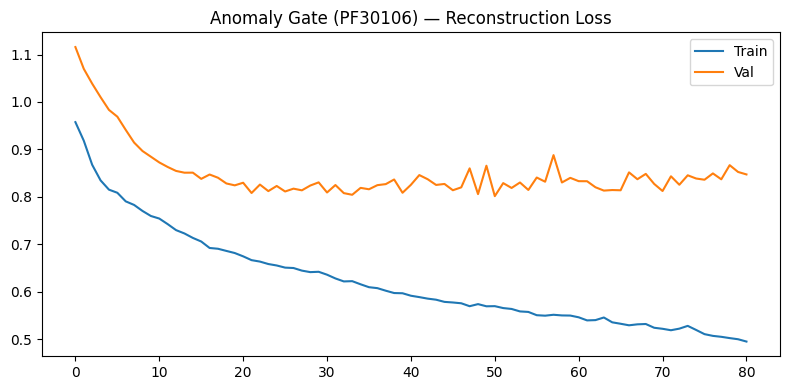

In [4]:
optimizer    = torch.optim.Adam(gate.parameters(), lr=1e-3)
criterion    = nn.MSELoss()
best_val_loss = float('inf')
patience     = 0
PATIENCE     = 30
train_losses, val_losses = [], []

print(f'Training Anomaly Gate on {MACHINE_SERIAL} healthy data...')
for epoch in range(300):
    gate.train()
    batch_losses = []
    for xb, _ in ae_loader:
        optimizer.zero_grad()
        loss = criterion(gate(xb), xb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    gate.eval()
    with torch.no_grad():
        val_loss = criterion(gate(X_ae_test), X_ae_test).item()

    train_losses.append(np.mean(batch_losses))
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(gate.state_dict(), 'best_anomaly_gate_PF30106.pt')
        patience = 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {np.mean(batch_losses):.6f} | Val: {val_loss:.6f}')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.title(f'Anomaly Gate ({MACHINE_SERIAL}) — Reconstruction Loss')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_gate_PF30106_loss.png', dpi=150)
plt.show()

#### Compute Thresholds

Reconstruction Error on PF30106 Healthy Data:
  Mean : 0.686832
  Std  : 0.136323
  p95  : 0.874356  <- warning threshold
  p99  : 1.186382  <- critical threshold


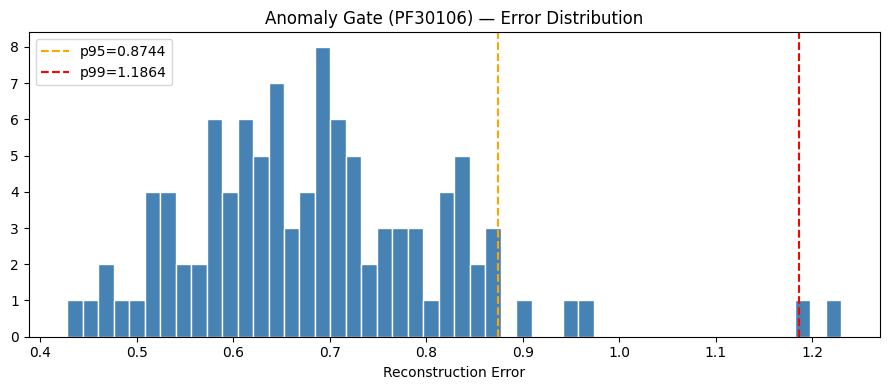

✅ Thresholds saved to ae_thresholds_PF30106.pkl


In [5]:
gate.load_state_dict(torch.load('best_anomaly_gate_PF30106.pt'))
gate.eval()
with torch.no_grad():
    recon  = gate(X_ae_test)
    errors = torch.mean(torch.abs(X_ae_test - recon), dim=(1,2)).cpu().numpy()

WARNING_THRESHOLD  = float(np.percentile(errors, 95))
CRITICAL_THRESHOLD = float(np.percentile(errors, 99))

print(f'Reconstruction Error on {MACHINE_SERIAL} Healthy Data:')
print(f'  Mean : {np.mean(errors):.6f}')
print(f'  Std  : {np.std(errors):.6f}')
print(f'  p95  : {WARNING_THRESHOLD:.6f}  <- warning threshold')
print(f'  p99  : {CRITICAL_THRESHOLD:.6f}  <- critical threshold')

plt.figure(figsize=(9,4))
plt.hist(errors, bins=50, color='steelblue', edgecolor='white')
plt.axvline(WARNING_THRESHOLD,  color='orange', linestyle='--', label=f'p95={WARNING_THRESHOLD:.4f}')
plt.axvline(CRITICAL_THRESHOLD, color='red',    linestyle='--', label=f'p99={CRITICAL_THRESHOLD:.4f}')
plt.title(f'Anomaly Gate ({MACHINE_SERIAL}) — Error Distribution')
plt.xlabel('Reconstruction Error')
plt.legend()
plt.tight_layout()
plt.savefig('anomaly_gate_PF30106_thresholds.png', dpi=150)
plt.show()

thresholds = {'warning': WARNING_THRESHOLD, 'critical': CRITICAL_THRESHOLD}
with open('ae_thresholds_PF30106.pkl', 'wb') as f: pickle.dump(thresholds, f)
print('✅ Thresholds saved to ae_thresholds_PF30106.pkl')